In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
from util import split_waveform_by_timestamps

token = os.environ.get("HUGGINGFACE_ACCESS_TOKEN")
mp3_file = "sample.mp3"

In [2]:
from pyannote.audio import Audio, Pipeline
from pyannote.audio.pipelines.utils.hook import ProgressHook
import torch

io = Audio(mono="downmix", sample_rate=16000)
waveform, sample_rate = io(mp3_file)

pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1", use_auth_token=token
)

pipeline.to(torch.device("cuda"))

with ProgressHook() as hook:
    diarization = pipeline(
        {"waveform": waveform, "sample_rate": sample_rate}, num_speakers=2, hook=hook
    )

Output()

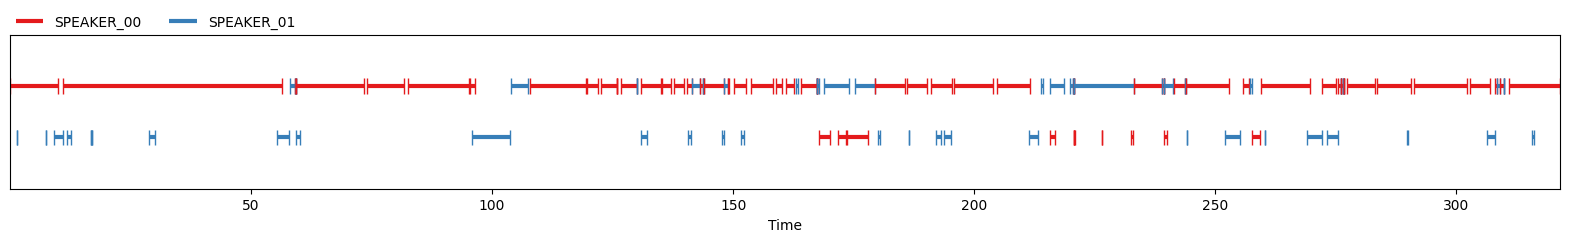

In [3]:
diarization

In [4]:
timestamps = []

for turn, _, speaker in diarization.itertracks(yield_label=True):
    timestamps.append((turn.start, turn.end, speaker))

In [5]:
split_waveform_by_timestamps(waveform, sample_rate, "out", timestamps)